#FINE TUNING REASONING MODELS

##0.REFERENCE AND CONTEXT

**Introduction**

Most traditional fine-tuning efforts focus on teaching models additional knowledge. In Chapter 16, we fine-tuned a foundation model to better understand financial concepts such as duration risk, Sharpe ratios, and diversification. While this improves domain expertise, it does not necessarily improve reasoning quality.

Reasoning models represent the next frontier in artificial intelligence. Rather than simply producing answers, reasoning models are trained to generate intermediate analytical steps before reaching conclusions. This structured process often improves transparency, consistency, and problem-solving ability.

The purpose of this notebook is to demonstrate reasoning fine-tuning. Instead of training on simple instruction-response pairs, we train on reasoning traces. Each example contains a question, multiple reasoning steps, and a conclusion. The model learns not only what answer to produce but also how to arrive at that answer.

The dataset focuses on financial decision-making scenarios involving portfolio construction, risk management, inflation, asset allocation, and pension fund management. Students will observe how reasoning examples differ from knowledge examples and how structured thought processes can be encoded into training data.

By the end of this notebook, students will understand how reasoning datasets are constructed, how reasoning traces can be used for fine-tuning, and why modern AI research increasingly focuses on improving reasoning rather than merely increasing knowledge.

##1.LIBRARIES AND ENVIRONMENT

**Explanation for Cell 1**

This cell prepares the environment, installs required libraries, establishes reproducibility, and creates project directories.

In [1]:
# CELL 1
# Environment Setup

!pip -q install transformers datasets accelerate evaluate

import json
import random
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_DIR = Path(
    "/content/chapter17_reasoning_finetuning"
)

ARTIFACT_DIR = PROJECT_DIR / "artifacts"
MODEL_DIR = PROJECT_DIR / "model"

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.6 MB/s eta 0:00:00
PyTorch: 2.11.0+cu128
CUDA: True


##2.SYNTHETIC REASONING DATASET

**Explanation for Cell 2**

This cell creates a synthetic reasoning dataset. Every example contains a question, a structured reasoning trace, and a final conclusion.

In [2]:
# CELL 2
# Create Synthetic Reasoning Dataset

reasoning_examples = []

topics = [

    "inflation hedges",
    "duration risk",
    "portfolio diversification",
    "private credit",
    "real estate allocation",
    "risk budgeting",
    "factor investing",
    "asset allocation",
    "pension liabilities",
    "interest rate risk"

]

for topic in topics:

    for i in range(50):

        example = {

            "question":
                f"Should a pension fund increase exposure to {topic}?",

            "reasoning": [

                f"Analyze the economic environment related to {topic}.",
                f"Review portfolio exposure to {topic}.",
                f"Evaluate diversification benefits.",
                f"Assess risk-adjusted return implications."

            ],

            "conclusion":
                f"A moderate allocation to {topic} may be justified depending on portfolio objectives."

        }

        reasoning_examples.append(
            example
        )

print(
    "Reasoning Examples:",
    len(reasoning_examples)
)

Reasoning Examples: 500


##3.LOADING THE TOKENIZER

**Explanation for Cell 3**

This cell loads the DistilGPT2 foundation model and tokenizer.

In [3]:
# CELL 3
# Load DistilGPT2

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

MODEL_NAME = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
)

model.config.pad_token_id = tokenizer.pad_token_id

print("Loaded:", MODEL_NAME)

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded: distilgpt2


##4.DATA CONFIGURATION FOR TRAINING

**Explanation for Cell 4**

This cell converts reasoning examples into structured reasoning traces suitable for fine-tuning.

In [4]:
# CELL 4
# Build Reasoning Templates

formatted_reasoning_examples = []

for example in reasoning_examples:

    formatted_text = f"""
Question:
{example['question']}

Reasoning Step 1:
{example['reasoning'][0]}

Reasoning Step 2:
{example['reasoning'][1]}

Reasoning Step 3:
{example['reasoning'][2]}

Reasoning Step 4:
{example['reasoning'][3]}

Conclusion:
{example['conclusion']}
"""

    formatted_reasoning_examples.append(
        formatted_text
    )

print(
    formatted_reasoning_examples[0]
)


Question:
Should a pension fund increase exposure to inflation hedges?

Reasoning Step 1:
Analyze the economic environment related to inflation hedges.

Reasoning Step 2:
Review portfolio exposure to inflation hedges.

Reasoning Step 3:
Evaluate diversification benefits.

Reasoning Step 4:
Assess risk-adjusted return implications.

Conclusion:
A moderate allocation to inflation hedges may be justified depending on portfolio objectives.



##5.THE TRAINING AND VALIDATION SETS

**Explanation for Cell 5**

This cell creates train and validation datasets.

In [5]:
# CELL 5
# Train Validation Split

from datasets import Dataset

dataset = Dataset.from_dict(
    {
        "text":
            formatted_reasoning_examples
    }
)

dataset = dataset.shuffle(
    seed=SEED
)

split = dataset.train_test_split(
    test_size=0.20,
    seed=SEED
)

train_dataset = split["train"]
validation_dataset = split["test"]

print(train_dataset)
print(validation_dataset)

Dataset({
    features: ['text'],
    num_rows: 400
})
Dataset({
    features: ['text'],
    num_rows: 100
})


##6.TOKENIZATION OF REASONING TRACES

**Explanation for Cell 6**

This cell tokenizes the reasoning traces. Labels are generated later by the data collator.

In [6]:
# CELL 6
# Tokenization

MAX_LENGTH = 256

train_dataset = train_dataset.with_format(None)
validation_dataset = validation_dataset.with_format(None)

def tokenize_function(batch):

    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=MAX_LENGTH
    )

train_dataset_tokenized = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

validation_dataset_tokenized = validation_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

train_dataset_tokenized = train_dataset_tokenized.with_format(None)
validation_dataset_tokenized = validation_dataset_tokenized.with_format(None)

print("Tokenization complete.")

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenization complete.


##7.FINE TUNING

**Explanation for Cell 7**

This cell performs reasoning fine-tuning using the same stable Trainer configuration that worked in Chapter 16.

In [9]:
# CELL 7
# Reasoning Fine-Tuning

from transformers import (
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

training_args = TrainingArguments(
    output_dir=str(MODEL_DIR),
    num_train_epochs=10,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=5e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    report_to="none",
    fp16=False,
    remove_unused_columns=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_tokenized,
    eval_dataset=validation_dataset_tokenized,
    data_collator=data_collator
)

training_result = trainer.train()

print(training_result)

Epoch,Training Loss,Validation Loss
1,0.025254,0.024524
2,0.024402,0.024669
3,0.026103,0.023631
4,0.025315,0.023290
5,0.024426,0.023566
6,0.024348,0.023348
7,0.023937,0.023480
8,0.023749,0.023159
9,0.023807,0.023430
10,0.023943,0.023362


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1000, training_loss=0.024528224945068358, metrics={'train_runtime': 43.6176, 'train_samples_per_second': 91.706, 'train_steps_per_second': 22.927, 'total_flos': 103836879028224.0, 'train_loss': 0.024528224945068358, 'epoch': 10.0})


##8.EVALUATION OF THE REASONING MODEL

**Explanation for Cell 8**

This cell evaluates the reasoning model and computes perplexity.

In [12]:
# CELL 8
# Evaluation

evaluation_results = trainer.evaluate()

eval_loss = float(
    evaluation_results["eval_loss"]
)

perplexity = float(
    np.exp(eval_loss)
)

reasoning_evaluation = {

    "eval_loss":
        eval_loss,

    "perplexity":
        perplexity,

    "validation_examples":
        len(validation_dataset_tokenized)
}

print(
    json.dumps(
        reasoning_evaluation,
        indent=2
    )
)

Training Loss,Validation Loss,Epoch
0.023943,0.023362,10


{
  "eval_loss": 0.023361796513199806,
  "perplexity": 1.0236368207924924,
  "validation_examples": 100
}


##9.COMPARISON OF BEFORE AND AFTER

**Explanation for Cell 9**

This cell compares reasoning behavior before and after fine-tuning.

In [14]:
# CELL 9
# Reasoning Before vs After
# Fixed device mismatch version.

from transformers import AutoModelForCausalLM

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

baseline_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME
)

baseline_model.config.pad_token_id = tokenizer.pad_token_id
model.config.pad_token_id = tokenizer.pad_token_id

baseline_model.to(device)
model.to(device)

baseline_model.eval()
model.eval()

question = """
Question:
Should a pension fund increase inflation hedges?

Reasoning Step 1:
"""

def generate_answer(
    current_model,
    prompt,
    max_new_tokens=120
):
    current_model.eval()

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        output = current_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    return tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )

baseline_output = generate_answer(
    baseline_model,
    question
)

reasoning_output = generate_answer(
    model,
    question
)

comparison_outputs = {
    "prompt": question,
    "baseline_output": baseline_output,
    "reasoning_model_output": reasoning_output
}

comparison_output_path = (
    ARTIFACT_DIR /
    "reasoning_before_after_comparison.json"
)

with open(
    comparison_output_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        comparison_outputs,
        f,
        indent=2
    )

print("=" * 80)
print("BASE MODEL")
print("=" * 80)
print(baseline_output)

print("\n")

print("=" * 80)
print("REASONING MODEL")
print("=" * 80)
print(reasoning_output)

print("\nSaved comparison to:", comparison_output_path)

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

BASE MODEL

Question:
Should a pension fund increase inflation hedges?

Reasoning Step 1:
If the government is to increase the rate of inflation, it should increase the rate of inflation.
Question:
If the government is to increase the rate of inflation, it should increase the rate of inflation.
Question:
If the government is to increase the rate of inflation, it should increase the rate of inflation.
Question:
If the government is to increase the rate of inflation, it should increase the rate of inflation.
Question:
If the government is to increase the rate of inflation, it should increase the rate of inflation.
Question:
If the government is to


REASONING MODEL

Question:
Should a pension fund increase inflation hedges?

Reasoning Step 1:
Analyze the economic environment related to inflation hedges.

Reasoning Step 2:
Review portfolio exposure to inflation hedges.

Reasoning Step 3:
Evaluate diversification benefits.

Reasoning Step 4:
Assess risk-adjusted return implications.

Concl

##10.REASONING PERFORMANCE METRICS

**Explanation for Cell 10**

This cell visualizes training loss and reasoning performance metrics.

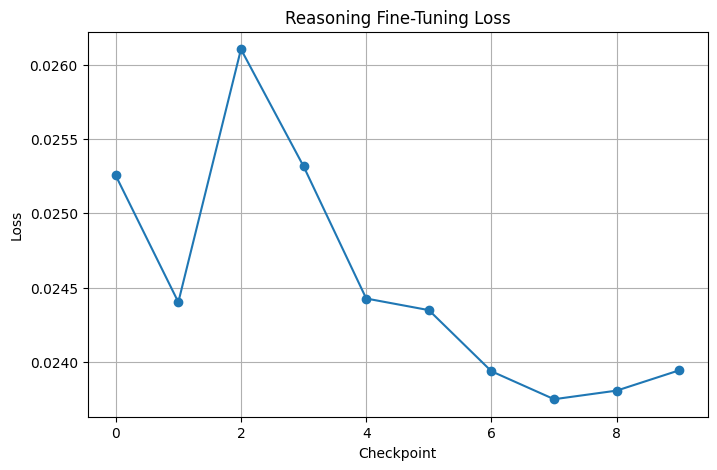

Final Evaluation Loss: 0.023361796513199806
Final Perplexity: 1.0236368207924924


In [15]:
# CELL 10
# Reasoning Quality Analysis

history = trainer.state.log_history

training_losses = []

for entry in history:

    if "loss" in entry:

        training_losses.append(
            entry["loss"]
        )

plt.figure(
    figsize=(8,5)
)

plt.plot(
    training_losses,
    marker="o"
)

plt.title(
    "Reasoning Fine-Tuning Loss"
)

plt.xlabel(
    "Checkpoint"
)

plt.ylabel(
    "Loss"
)

plt.grid(True)

plt.show()

print(
    "Final Evaluation Loss:",
    eval_loss
)

print(
    "Final Perplexity:",
    perplexity
)

##11.SUMMARIZATION AND EXPLANATION

In [16]:
# CELL 11
# GPT-5.2 Interpretation

from google.colab import userdata
from openai import OpenAI

client = OpenAI(
    api_key=userdata.get(
        "OPENAI_API_KEY"
    )
)

summary = {

    "model":
        MODEL_NAME,

    "training_examples":
        len(train_dataset_tokenized),

    "validation_examples":
        len(validation_dataset_tokenized),

    "evaluation_loss":
        eval_loss,

    "perplexity":
        perplexity
}

response = client.responses.create(
    model="gpt-5.2",
    input=f"""
Analyze this reasoning-model
fine-tuning experiment.

Return strict JSON.

{json.dumps(summary, indent=2)}
"""
)

print(
    response.output_text
)

{
  "summary": {
    "model": "distilgpt2",
    "training_examples": 400,
    "validation_examples": 100,
    "metrics": {
      "evaluation_loss": 0.023361796513199806,
      "perplexity": 1.0236368207924924
    },
    "overall_assessment": "Metrics are unusually strong (very low loss and perplexity near 1), which is atypical for general language modeling and suggests an evaluation setup that may be too easy, has leakage, or is not representative."
  },
  "sanity_checks": {
    "perplexity_matches_loss": {
      "check": "perplexity ≈ exp(loss)",
      "exp_loss": 1.0236368082728784,
      "reported_perplexity": 1.0236368207924924,
      "match": true
    },
    "dataset_split": {
      "train_fraction": 0.8,
      "validation_fraction": 0.2,
      "comment": "Split is conventional, but absolute sizes are small."
    }
  },
  "interpretation": {
    "what_the_metrics_imply": [
      "Perplexity ~1.02 implies the model assigns extremely high probability to the correct next tokens on av

##12.CONCLUSIONS

**Conclusion**

This notebook introduced one of the most important concepts in modern artificial intelligence: reasoning fine-tuning. Unlike traditional instruction tuning, which teaches a model additional knowledge, reasoning fine-tuning teaches a model how to structure thought processes before producing conclusions.

Students observed how reasoning traces can be represented as training examples. Each example included a question, multiple intermediate analytical steps, and a final recommendation. This structure allows the model to learn reasoning patterns rather than memorizing isolated answers.

The distinction between knowledge and reasoning is fundamental. A model may possess extensive factual information yet struggle with complex decision-making. Conversely, a model with strong reasoning capabilities can often solve unfamiliar problems by applying learned analytical structures. Modern AI research increasingly focuses on improving reasoning quality because reasoning is a key driver of generalization and problem-solving performance.

The notebook demonstrated the complete reasoning fine-tuning workflow: dataset construction, reasoning-template generation, tokenization, supervised training, evaluation, and behavioral comparison. Students saw how a foundation model can be adapted to produce more structured and transparent decision processes.

Reasoning traces also improve interpretability. Rather than generating conclusions directly, the model exposes intermediate analytical steps. This transparency can be particularly valuable in finance, healthcare, law, and governance where stakeholders need to understand how decisions are reached.

Most importantly, this chapter introduced the conceptual foundations that support modern reasoning architectures and agentic systems. Planning, decomposition, reflection, and structured inference all emerge naturally from reasoning-oriented training data.

The next chapter extends these ideas further by introducing Multi-Agent Systems. Instead of a single reasoning model, multiple specialized agents will collaborate, debate, critique, and refine solutions. This transition represents another major step toward autonomous AI systems capable of sophisticated collective intelligence.